In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_diabetes
import numpy as np

In [2]:
x,y=load_diabetes(return_X_y=True)

In [5]:
lr=LinearRegression()


In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [9]:
from sklearn.metrics import r2_score

In [7]:
lr.fit(x_train,y_train)

LinearRegression()

In [8]:
y_pred=lr.predict(x_test)

In [10]:
r2_score(y_test,y_pred)

0.45260276297191937

In [ ]:
class PracticalMLR:

    def __init__(self):
        self.coef_=None
        self.intercept_=None
        
    def fit(self,x_train,y_train):
        
        x_train_transfer=np.insert(x_train,0,1,axis=1)

        betas=np.linalg.inv(np.dot(x_train_transfer.T,x_train_transfer)).dot(x_train_transfer.T).dot(y_train)

        self.coef_=betas[1:]
        self.intercept_=betas[0]
        print(self.intercept_,self.coef_)
        

    def predict(self,x_test):
        y_pred=np.dot(x_test,self.coef_)+self.intercept_
        return y_pred    

In [20]:
pmlr=PracticalMLR()

pmlr.fit(x_train,y_train)


151.34560453986 [  37.90402135 -241.96436231  542.42875852  347.70384391 -931.48884588
  518.06227698  163.41998299  275.31790158  736.1988589    48.67065743]


In [21]:
y_pred=pmlr.predict(x_test)

In [22]:
r2_score(y_test,y_pred)

0.4526027629719189

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [24]:
vif=[]
for i in range(x_train.shape[1]):
    vif.append(variance_inflation_factor(x_train,i))

In [26]:
pd.DataFrame({"vif":vif})

,vif
0,1.217580
1,1.268846
2,1.574980
3,1.422929
4,55.257986
5,35.765403
6,14.290571
7,9.333225
8,10.077560
9,1.502008


In [27]:
import seaborn as sns

In [30]:
residual=y_test-y_pred

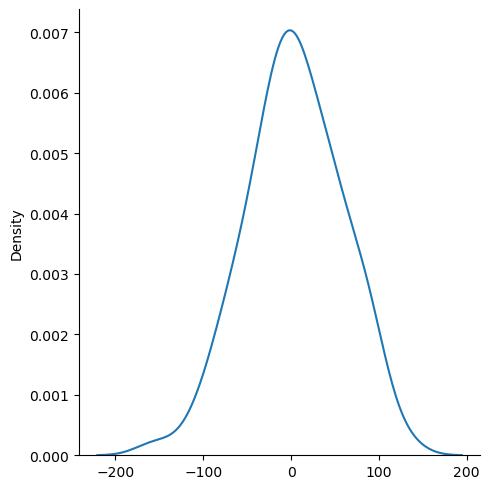

In [31]:
sns.displot(residual,kind="kde")

In [32]:
sns.scatterplot(y_pred,residual)

TypeError: scatterplot() takes from 0 to 1 positional arguments but 2 were given

In [33]:
import matplotlib.pyplot as plt

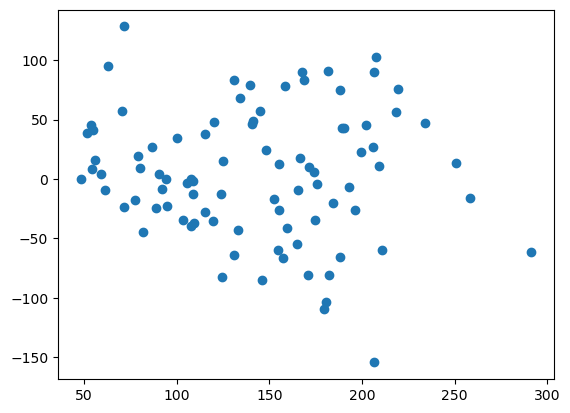

In [34]:
plt.scatter(y_pred,residual)

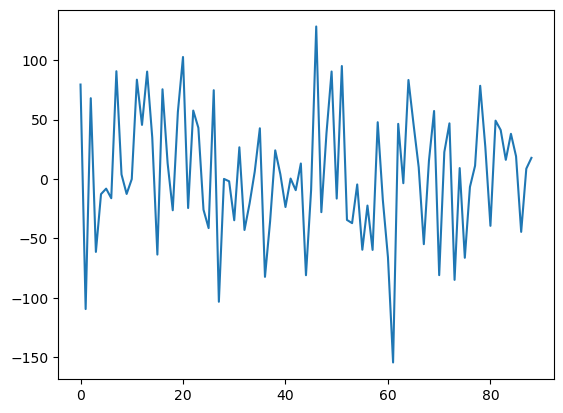

In [35]:
plt.plot(residual)